## About
 - model is a little more complex that ae_conv
 - in the bottleneck encoder compresses given histogram to 22 dimensions and creates 16 feature maps 
 - model is better at reconstructing data alghtough still reconstructs some oddly (eg. hist No. 1)
 - most of the other histograms are reconstructed better - eg. hist No. 71
 - next main goal is to get create functional model with KLDiv loss
    - model works with the loss criterion but does not lear crap

- **the current model state works very good write it in the thesis and finish autoencoders**
 

In [118]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from src.plotting_styles import apply_global_style

In [119]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [120]:
from src.load_sam_data import load_dataset
from src.autoencoders import prepocess_data

dataset = load_dataset("FJ")
dataset = prepocess_data(dataset)

..\data\FJ\FI01X1\FI01X1_ch


In [121]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [122]:
from src.autoencoders import HistDataset
from torch.utils.data import DataLoader

batch_size = 32
dataset = HistDataset(dataset)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [123]:
pt = dataset[34]

# to get the actual lenght
pt_len = len(pt[0])
pt = pt.reshape(1, 1, pt_len)
encoder = nn.Sequential(
            nn.Conv1d(1, 4, kernel_size=2),  
            nn.BatchNorm1d(4),
            nn.ReLU(),
            
            nn.Conv1d(4, 8, kernel_size=6, stride=2, padding=1),  
            nn.BatchNorm1d(8),
            nn.ReLU(),

            
            nn.Conv1d(8, 16, kernel_size=6, stride=2, padding=1), 
            nn.BatchNorm1d(16),
            nn.Sigmoid()
        )

print(f"The encoded data shape: {encoder(pt).shape}")

The encoded data shape: torch.Size([1, 16, 22])


In [124]:
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 4, kernel_size=2),  
            nn.BatchNorm1d(4),
            nn.ReLU(),
            
            nn.Conv1d(4, 8, kernel_size=6, stride=2, padding=1),  
            nn.BatchNorm1d(8),
            nn.ReLU(),

            
            nn.Conv1d(8, 16, kernel_size=6, stride=2, padding=1), 
            nn.BatchNorm1d(16),
            nn.Sigmoid()
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 4, kernel_size=4, stride=2),  
            nn.BatchNorm1d(4),
            nn.ReLU(),
            
            nn.ConvTranspose1d(4, 1, kernel_size=6, stride=2),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [125]:
#criterion = torch.nn.KLDivLoss(reduction='batchmean')
ae = AE()
#criterion = torch.nn.KLDivLoss()
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params=ae.parameters(), lr=0.001)

In [126]:
from src.autoencoders import train_ae

losses, ae = train_ae(n_epochs=40, dataloader=dataloader, model=ae, optimizer=optimizer, criterion=criterion)

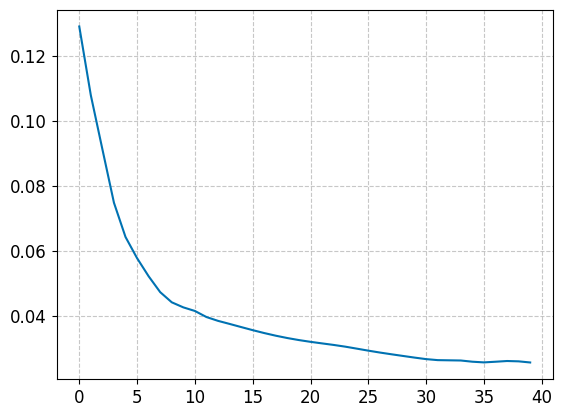

In [127]:
apply_global_style()
plt.plot(range(len(losses)), losses)
plt.show()

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


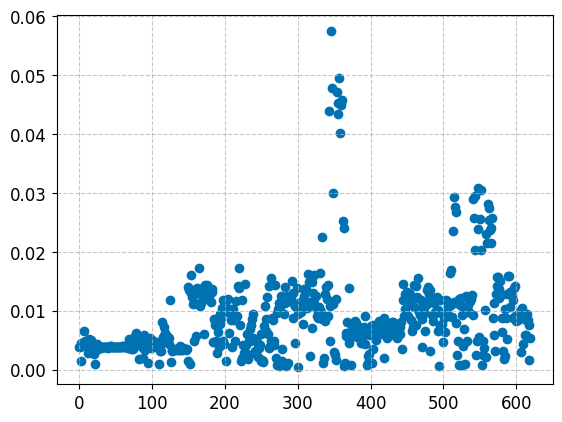

In [128]:
from src.autoencoders import eval_and_plot_score
apply_global_style()
score = eval_and_plot_score(model=ae, dataloader=dataloader, criterion=criterion)

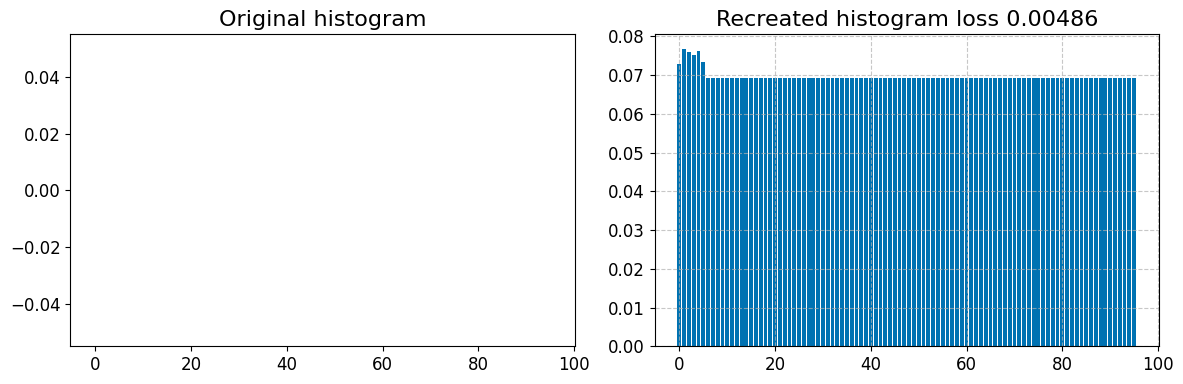

In [136]:
idx = 15

x = dataset[idx].unsqueeze(0)              
pred = ae(x)                               
pred = pred.detach().cpu().numpy().squeeze() 

# loss
mse = nn.MSELoss()
target = dataset[idx].detach().cpu().numpy().squeeze()

loss = round(mse(torch.from_numpy(target), torch.from_numpy(pred)).item(), 5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), dataset[idx][0])
axes[0].set_title("Original histogram")

axes[1].bar(range(len(pred)), pred)
axes[1].set_title(f"Recreated histogram loss {loss}")

apply_global_style() # fix so both images have plotting styles
plt.tight_layout()
plt.show()

In [130]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [346, 357, 347, 354, 361, 359, 356, 360, 343, 355]
lowest scores [274, 494, 300]


In [131]:
#torch.save(ae, 'functional_ae_conv_2.pth')

In [132]:
(dataset[0] == dataset[0]).all()

tensor(True)

In [133]:
preds = list()

with torch.no_grad():
    for idx, data in enumerate(dataset):
        data = data.unsqueeze(0)     
        pred = ae(data).numpy()
         
        for p in preds:
            if (pred == p).all():
                break
        else:
            preds.append(pred)
        
        if idx % 100 == 0: 
            print(idx)

0
100
200
300
400
500
600
